In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pro_solvers import solve_heat, solve_heat2d, image_diff
from mpl_toolkits.mplot3d import Axes3D
from skimage import data, io
#from pde_solvers import fdm
plt.rcParams["figure.figsize"] = (5, 3)  # width x height in inches
from matplotlib.animation import FuncAnimation
#from manim import *
#from manim.utils.ipython_magic import ManimMagic
#get_ipython().register_magics(ManimMagic)

#%load_ext manim

Now test the 2D Case. 

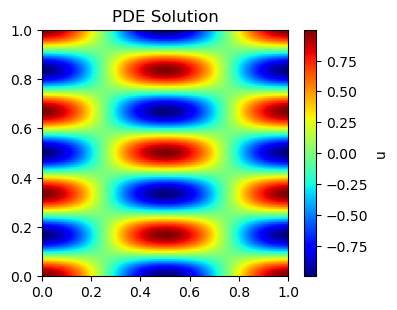

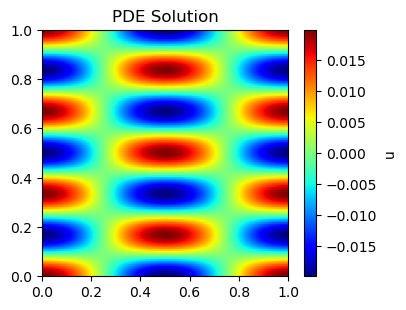

In [26]:
# PDE: u_t = alpha u_xx
alpha = 1.0
Lx = 1.0
Ly = 1.0
dx = 0.01
dy = 0.01
dt = 0.0001
t_end = 0.01  # Try varying this

# Initial condition: sin(3 pi x)
#u0 = lambda x: np.sin(3 * np.pi * x) + 1
#u0 = lambda x: x**2
#u0 = lambda x : np.where(np.sin(100*x) > 0.0, 1.0, 0.0)
#u0 = lambda x: np.where(np.abs(x) < .1, 100.0, 0.0)

N = 100
A = 1#np.random.randint(0,N)
j = 2#np.random.rand(0,N)
k = 6#np.random.rand(0,N)
def u0(x, y):
    return A * np.sin(j * np.pi * x) * np.sin(k * np.pi * y)


def u_exact(x, y, t):
    return A * np.sin(j * np.pi * x) * np.sin(k * np.pi * y) * np.exp(-((k * np.pi)**2 + (j * np.pi)**2) * t)



T, U = solve_heat2d(u0, alpha, dx, dy, t_end, Lx, Ly)

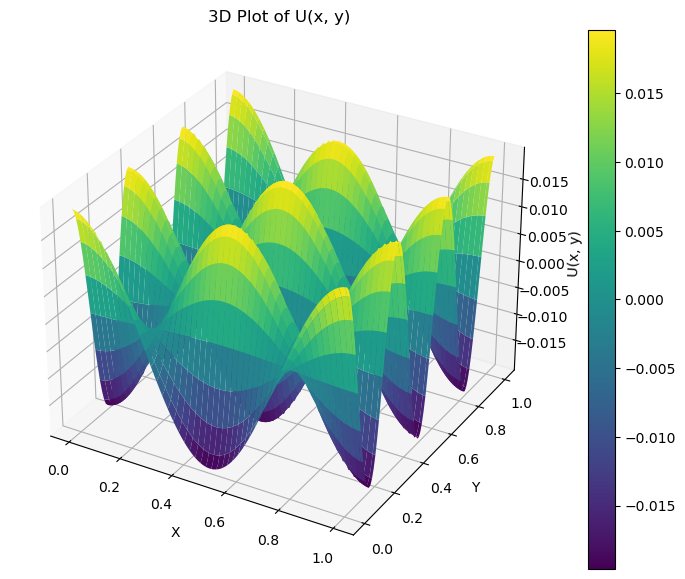

In [28]:
Nx = int(Lx / dx)
Ny = int(Ly / dy)
x = np.linspace(0, Lx, Nx)  # x values from 0 to Lx
y = np.linspace(0, Ly, Ny)  # y values from 0 to Ly
X, Y = np.meshgrid(x, y) 

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='viridis', edgecolor='none')
fig.colorbar(surf)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('3D Plot of U(x, y)')


plt.show()

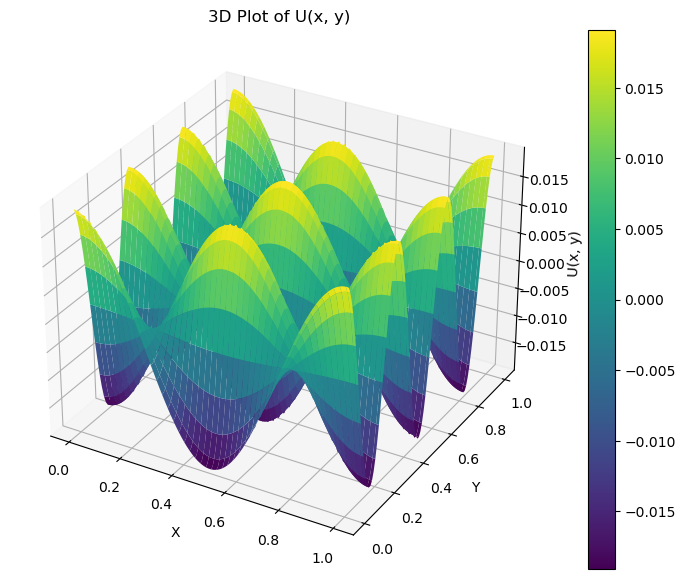

In [30]:
u_e = lambda x,y: u_exact(x, y, t_end)
V = u_e(X,Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, u_e(X,Y), cmap='viridis', edgecolor='none')
fig.colorbar(surf)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('3D Plot of U(x, y)')


plt.show()

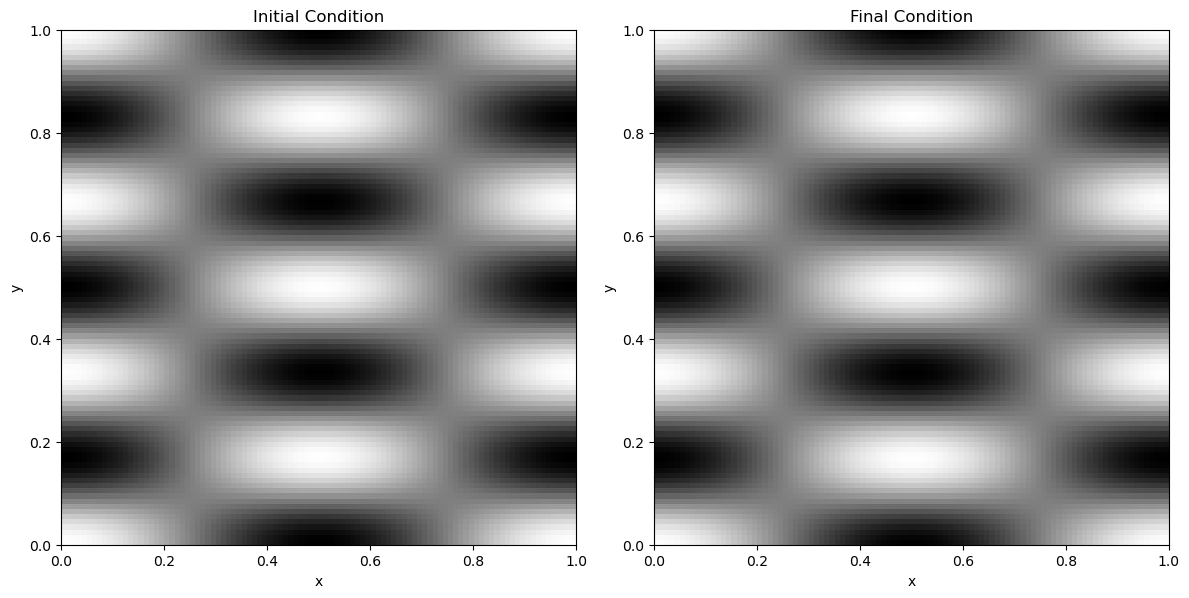

In [31]:
#Convert to image data 
U0 = u0(X,Y)
offset = U0.min() if U0.min() < 0 else 0
U0 = U0 - offset
U0_normalized = (U0 - np.min(U0)) / (np.max(U0) - np.min(U0))
U0_scaled = (U0_normalized * 255).astype(np.uint8)

offset = U.min() if U.min() < 0 else 0
U = U - offset
U_normalized = (U - np.min(U)) / (np.max(U) - np.min(U))
U_scaled = (U_normalized * 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the initial condition
axs[0].imshow(U0_scaled, cmap='gray', origin='lower', extent=(0, Lx, 0, Ly))
axs[0].set_title('Initial Condition')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

# Plot the final condition
axs[1].imshow(U_scaled, cmap='gray', origin='lower', extent=(0, Lx, 0, Ly))
axs[1].set_title('Final Condition')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')


# Show the plot
plt.tight_layout()
plt.show()

0.0
0.45
0.9
1.35
1.8


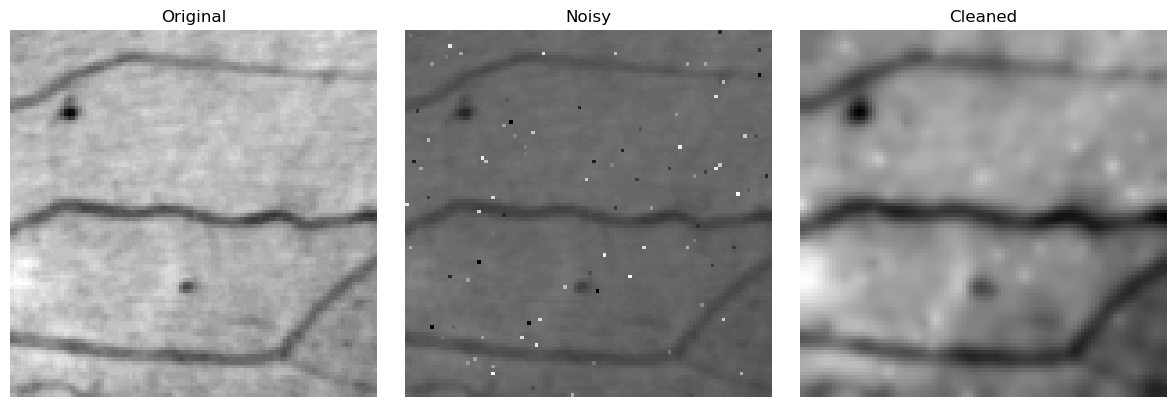

In [37]:
#original image 
#img = data.camera()
#img = data.coins()
img = data.microaneurysms()

#noisy image
img_noise = img.copy()
for row in range(img.shape[0]):
    for col in range(img.shape[1]):
        if np.random.randint(100) == 1:
            img_noise[row,col] = np.random.randint(255)

#"cleaned" image
alpha = 1
t_end = 2
img_cln = image_diff(img_noise, alpha, t_end)


# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(img_noise, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Cleaned")
plt.imshow(img_cln, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()